In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

In [48]:
# 1. 데이터 로드 및 전처리.

columns = ["id", "subject", "activity", "timestamp", "x", "y", "z"]
df = pd.read_csv('/content/drive/MyDrive/data/WISDM.csv', header=None, names=columns)

df = df[df['activity'].isin(['Jogging', 'Sitting'])]
df = df.drop(columns=["id", "subject", "timestamp"])
df

,activity,x,y,z
0,Jogging,-0.694638,12.680544,0.503953
1,Jogging,5.012288,11.264028,0.953424
2,Jogging,4.903325,10.882658,-0.081722
3,Jogging,-0.612916,18.496431,3.023717
4,Jogging,-1.184970,12.108489,7.205164
...,...,...,...,...
1036605,Jogging,1.420000,-2.340000,1.950000
1036606,Jogging,-0.800000,0.230000,0.950000
1036607,Jogging,-0.110000,9.110000,-0.930000
1036608,Jogging,-2.560000,20.040000,0.080000


In [49]:
df.activity.value_counts()

,count
activity,
Jogging,325975
Sitting,54876


In [50]:
df.shape

(380851, 4)

In [51]:
# 결측치 확인

df.isnull().values.any()

np.False_

In [52]:
df

,activity,x,y,z
0,Jogging,-0.694638,12.680544,0.503953
1,Jogging,5.012288,11.264028,0.953424
2,Jogging,4.903325,10.882658,-0.081722
3,Jogging,-0.612916,18.496431,3.023717
4,Jogging,-1.184970,12.108489,7.205164
...,...,...,...,...
1036605,Jogging,1.420000,-2.340000,1.950000
1036606,Jogging,-0.800000,0.230000,0.950000
1036607,Jogging,-0.110000,9.110000,-0.930000
1036608,Jogging,-2.560000,20.040000,0.080000


In [53]:
df.activity.value_counts()

,count
activity,
Jogging,325975
Sitting,54876


In [55]:
# 라벨 이름
LABELS = ["Normal", "Fraud"]

# 'Jogging'은 정상(0), 'Sitting'은 이상(1)
df['Class'] = df['activity'].apply(lambda x: 0 if x == 'Jogging' else 1)

# 정상(normal)과 이상(fraud) 데이터 분리
normal = df[df.Class == 0]
frauds = df[df.Class == 1]

print("정상 데이터 (Jogging):", normal.shape)
print("이상 데이터 (Sitting):", frauds.shape)

정상 데이터 (Jogging): (325975, 5)
이상 데이터 (Sitting): (54876, 5)


In [64]:
from sklearn.preprocessing import StandardScaler

data = df[['x', 'y', 'z']]
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

In [57]:
RANDOM_SEED = 42
X_train, X_test = train_test_split(data_scaled, test_size=0.2, random_state=RANDOM_SEED)

# 오직 정상 데이터만 학습용으로 사용
X_train = X_train[df.iloc[X_train.shape[0]*0:len(X_train)].Class == 0] if 'Class' in df.columns else X_train
# 위 코드는 안전하게 Class 기준 필터링 (Jogging만 학습)
X_train = df[df.Class == 0][['x', 'y', 'z']].values
X_test = df[['x', 'y', 'z']].values
y_test = df['Class'].values

print("훈련 데이터 크기:", X_train.shape)
print("테스트 데이터 크기:", X_test.shape)

훈련 데이터 크기: (325975, 3)
테스트 데이터 크기: (380851, 3)


In [58]:
input_dim = X_train.shape[1]
encoding_dim = 8

input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)
encoded = Dense(int(encoding_dim / 2), activation='relu')(encoded)
decoded = Dense(int(encoding_dim / 2), activation='relu')(encoded)
decoded = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

autoencoder.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 8)              │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 103 (412.00 B)

 Trainable params: 103 (412.00 B)

 Non-trainable params: 0 (0.00 B)

In [59]:
history = autoencoder.fit(
    X_train, X_train,
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_split=0.1
)

Epoch 1/50
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 34.9887 - val_loss: 3.6941
Epoch 2/50
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 3.5387 - val_loss: 0.0624
Epoch 3/50
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0335 - val_loss: 0.0050
Epoch 4/50
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0043 - val_loss: 0.0015
Epoch 5/50
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0014 - val_loss: 5.3286e-04
Epoch 6/50
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 5.1589e-04 - val_loss: 4.2673e-04
Epoch 7/50
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 3.1712e-04 - val_loss: 9.3311e-05
Epoch 8/50
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 2.0549e-04 - val_loss: 5.3269e-05
Epoch 9/50
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.3969e-04 - val_loss: 1.3511e-05
Epoch 10/50
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.4066e-04 - val_loss: 7.6487e-06
Epoch 11/50
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.5634e-04 

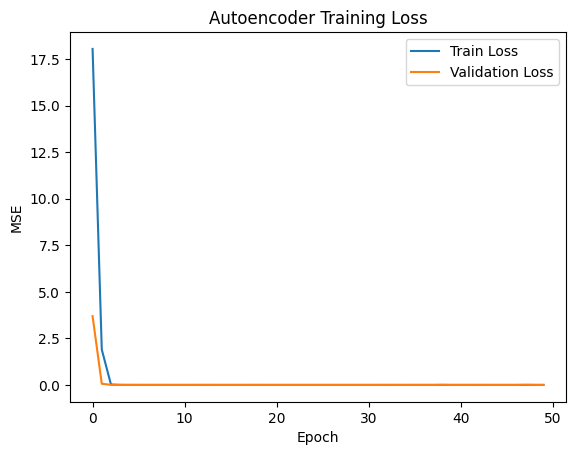

In [60]:
# 학습 손실 그래프
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Autoencoder Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()

In [61]:
predictions = autoencoder.predict(X_test)
mse = np.mean(np.power(X_test - predictions, 2), axis=1)
error_df = pd.DataFrame({'reconstruction_error': mse, 'true_class': y_test})

print(error_df.head())

11902/11902 ━━━━━━━━━━━━━━━━━━━━ 15s 1ms/step
   reconstruction_error  true_class
0              0.000033           0
1              0.000031           0
2              0.000026           0
3              0.000079           0
4              0.000057           0


Threshold (95th percentile): 9.748298922767438e-05


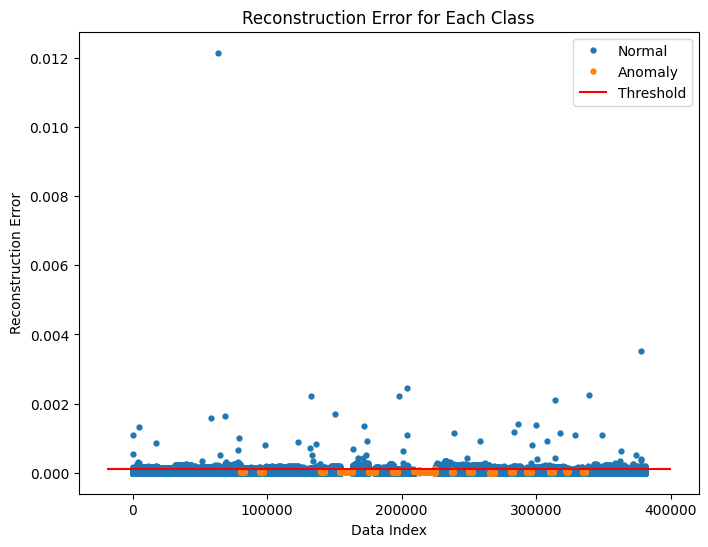

In [62]:
threshold = np.percentile(error_df.reconstruction_error, 95)
print("Threshold (95th percentile):", threshold)

groups = error_df.groupby('true_class')
fig, ax = plt.subplots(figsize=(8,6))
for name, group in groups:
    ax.plot(group.index, group.reconstruction_error, marker='o', ms=3.5, linestyle='',
            label="Anomaly" if name == 1 else "Normal")
ax.hlines(threshold, ax.get_xlim()[0], ax.get_xlim()[1], colors="r", label='Threshold')
ax.legend()
plt.title("Reconstruction Error for Each Class")
plt.ylabel("Reconstruction Error")
plt.xlabel("Data Index")
plt.show()


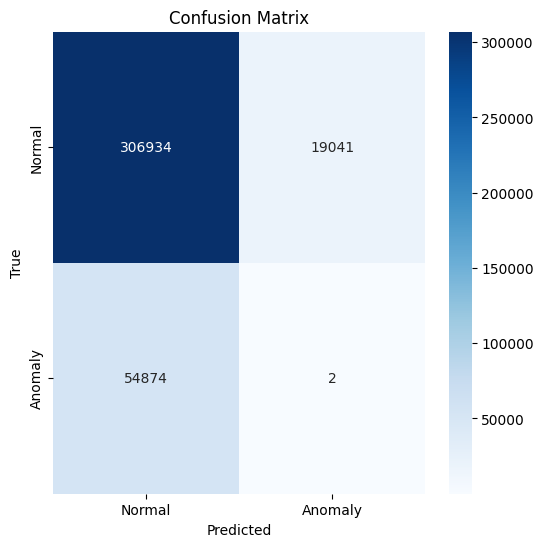

              precision    recall  f1-score   support

      Normal       0.85      0.94      0.89    325975
     Anomaly       0.00      0.00      0.00     54876

    accuracy                           0.81    380851
   macro avg       0.42      0.47      0.45    380851
weighted avg       0.73      0.81      0.76    380851



In [63]:
import seaborn as sns

y_pred = [1 if e > threshold else 0 for e in error_df.reconstruction_error.values]

conf_matrix = confusion_matrix(error_df.true_class, y_pred)
plt.figure(figsize=(6,6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Anomaly"],
            yticklabels=["Normal", "Anomaly"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print(classification_report(error_df.true_class, y_pred, target_names=["Normal", "Anomaly"]))